## Name: Paras Shah
## Roll number: 25/AFI/08

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Activation functions

In [2]:
def relu(z):
    return np.maximum(0, z)

def softmax(z):
    max_z = np.max(z, axis=0, keepdims=True)
    numerator = np.exp(z - max_z)
    denominator = np.sum(numerator, axis=0, keepdims=True)
    return numerator / denominator

def back_relu(z):
    return (z > 0).astype(float)

# 2. Initialize parameters (weights and bias)

In [3]:
def initialize_parameters(dims):
    parameters = {}
    for i in range(1, len(dims)):
        parameters["W" + str(i)] = np.random.randn(dims[i], dims[i - 1]) * 0.01
        parameters["b" + str(i)] = np.zeros((dims[i], 1))
    return parameters

# 3. Forward propagation

In [4]:
def forward_prop(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2

    for l in range(1, L):
        A_prev = A
        W = parameters['W' + str(l)]
        b = parameters['b' + str(l)]
        Z = np.dot(W, A_prev) + b
        linear_cache = (A_prev, W, b)

        A = relu(Z)
        activation_cache = Z

        cache = (linear_cache, activation_cache)
        caches.append(cache)

    W = parameters['W' + str(L)]
    b = parameters['b' + str(L)]
    Z = np.dot(W, A) + b
    linear_cache = (A, W, b)

    AL = softmax(Z)
    activation_cache = Z

    cache = (linear_cache, activation_cache)
    caches.append(cache)

    return AL, caches

# 4. Cost function

In [5]:
def find_cost(AL, Y):
    m = Y.shape[1]
    cost = -np.sum(Y * np.log(AL + 1e-12)) / m
    return cost

# 5. Backward propagation

In [6]:
def backward_prop(X, Y, caches):
    grads = {}
    L = len(caches)
    m = X.shape[1]
    Y = Y.reshape(X.shape)

    dZ = X - Y
    linear_cache, _ = caches[L - 1]
    A_prev, W, b = linear_cache

    grads["dW" + str(L)] = (1.0 / m) * np.dot(dZ, A_prev.T)
    grads["db" + str(L)] = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)
    grads["dA" + str(L - 1)] = np.dot(W.T, dZ)

    for l in reversed(range(L - 1)):
        linear_cache, activation_cache = caches[l]
        A_prev, W, b = linear_cache
        Z = activation_cache

        dZ = grads["dA" + str(l + 1)] * back_relu(Z)
        grads["dW" + str(l + 1)] = (1.0 / m) * np.dot(dZ, A_prev.T)
        grads["db" + str(l + 1)] = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)
        grads["dA" + str(l)] = np.dot(W.T, dZ)

    return grads

# 6. Update parameters

In [7]:
def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(L):
        parameters["W" + str(l+1)] = parameters["W" + str(l+1)] - learning_rate * grads["dW" + str(l+1)]
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - learning_rate * grads["db" + str(l+1)]
    return parameters

# 7. Model training function

In [14]:
from tqdm import tqdm
def train(X, Y, dims, learning_rate=0.005, iterations=150):
    costs = []
    accuracies = []
    parameters = initialize_parameters(dims)

    with tqdm(range(iterations), desc="Training", unit="iter") as pbar:
        for i in pbar:
            AL, caches = forward_prop(X, parameters)
            cost = find_cost(AL, Y)

            y_pred = np.argmax(AL, axis=0)
            y_true = np.argmax(Y, axis=0)
            accuracy = np.mean(y_pred == y_true)

            grads = backward_prop(AL, Y, caches)
            parameters = update_parameters(parameters, grads, learning_rate)
            costs.append(cost)
            accuracies.append(accuracy)

            if i % 15 == 0:
                tqdm.write(f"Iteration {i}: Loss = {cost:.2f}, Accuracy = {accuracy:.2f}")
                pbar.set_postfix(loss=f"{cost:.2f}", accuracy=f"{accuracy:.2f}")

    return parameters, costs, accuracies

# 8. Loading MNIST dataset

In [10]:
import pandas as pd
def load_data():
	train = pd.read_csv('mnist_train.csv')
	X_train = train.drop(columns=['label']).to_numpy()
	y_train = train['label'].to_numpy()

	test = pd.read_csv('mnist_test.csv')
	X_test = test.drop(columns=['label']).to_numpy()
	y_test = test['label'].to_numpy()

	X_train = X_train.T
	X_test = X_test.T
	y_train = np.eye(10)[y_train].T
	y_test = np.eye(10)[y_test].T

	return X_train, X_test, y_train, y_test

In [11]:
X_train, X_test, y_train, y_test = load_data()

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(784, 60000)
(784, 10000)
(10, 60000)
(10, 10000)


# 9. Training the model

In [15]:
model, loss_history, accuracy_history = train(X_train, y_train, dims=[X_train.shape[0], 500, 300, 300, 100, 10])

Training:   1%|          | 1/150 [00:14<35:55, 14.47s/iter, accuracy=0.09, loss=2.30]

Iteration 0: Loss = 2.30, Accuracy = 0.09


Training:  11%|█         | 16/150 [03:00<24:14, 10.85s/iter, accuracy=0.11, loss=2.30]

Iteration 15: Loss = 2.30, Accuracy = 0.11


Training:  21%|██        | 31/150 [05:44<21:54, 11.05s/iter, accuracy=0.12, loss=2.30]

...

Training:  81%|████████  | 121/150 [22:10<05:12, 10.77s/iter, accuracy=0.29, loss=2.30]

Iteration 120: Loss = 2.30, Accuracy = 0.29


Training:  91%|█████████ | 136/150 [24:53<02:30, 10.73s/iter, accuracy=0.30, loss=2.30]

Iteration 135: Loss = 2.30, Accuracy = 0.30


Training: 100%|██████████| 150/150 [27:41<00:00, 11.07s/iter, accuracy=0.30, loss=2.30]


# 10. Visualizing performance

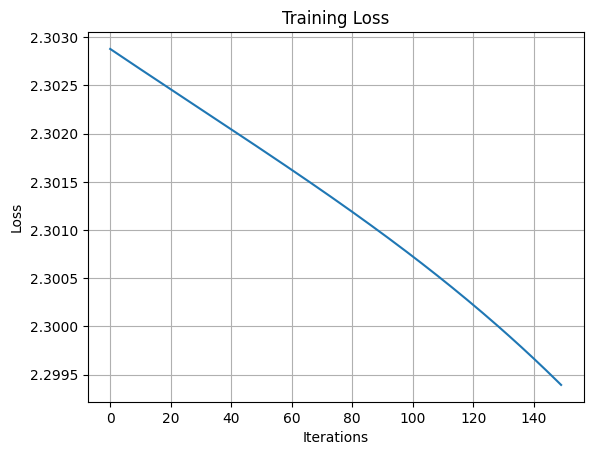

In [16]:
# Loss graph
plt.plot(loss_history)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

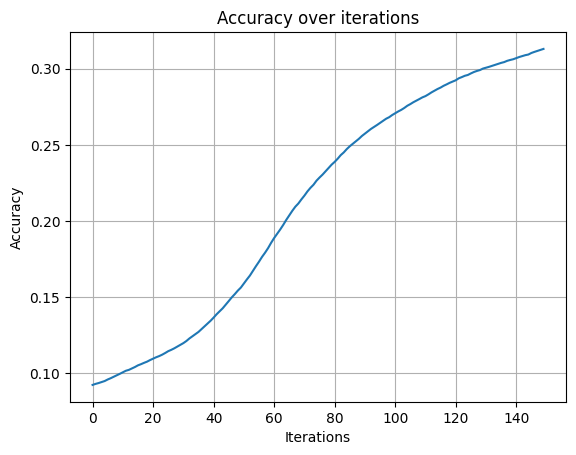

In [18]:
# Accuracy graph
plt.plot(accuracy_history)
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.title('Accuracy over iterations')
plt.grid(True)
plt.show()

# 11. Saving model into secondary storage

In [19]:
import pickle
def save_model(parameters, filename):
	with open(filename, "wb") as f:
		pickle.dump(parameters, f)

	print(f"Model saved to {filename}")

In [20]:
save_model(model, "mnist.pkl")

Model saved to mnist.pkl
